# 03 — Regresión de Edad v2 · Completo (Colab)

**Mejoras vs v1 (MAE 6.9 | RMSE 8.8 | R² 0.711):**
- Dataset: NIH + CheXpert (~96 k imgs) en lugar de solo NIH (~47 k)
- Normalización de edad con `StandardScaler` → entrenamiento más estable
- Cabeza: `Dense(512) → BN → Dense(256) → BN → Dense(1)` (vs `Dense(256) → Dense(1)` en v1)
- **Huber loss** (delta=1.5): más robusto a outliers de edad que MAE puro
- Fine-tuning de **80 capas** del backbone (vs 50 en v1)
- Augmentation más agresivo (rotación 12°, zoom 12%, shift 8%)

**Prerequisito:** `backbone_densenet121_v3.h5` en `Vena/checkpoints/` (generado por clasificación NB02).

**Archivos que produce:**
- `regresion_v2.h5` — mejor modelo
- `curvas_regresion_v2.png` — curvas de entrenamiento
- `scatter_regresion_v2.png` — scatter real vs predicho
- `backbone_reg_v2.h5` — backbone fine-tuneado (para NB04 clustering)


## Celda 1 — Verificación de GPU

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU encontrada: {gpus[0].name}")
    print("El entrenamiento usará aceleración por GPU.")
else:
    raise SystemError(
        "No se encontró GPU.\n"
        "Ir a: Entorno de ejecución → Cambiar tipo → Acelerador: T4 GPU → Guardar."
    )

GPU encontrada: /physical_device:GPU:0
El entrenamiento usará aceleración por GPU.


## Celda 2 — Montar Drive y definir rutas

In [2]:
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive")

# ── Raíz del proyecto ─────────────────────────────────────────────────────────
ruta_vena        = Path("/content/drive/MyDrive/Vena")
ruta_checkpoints = ruta_vena / "checkpoints"
ruta_datasets    = ruta_vena / "Notebooks" / "Datasets"

# ── Backbone del NB02 ─────────────────────────────────────────────────────────
ruta_backbone = ruta_checkpoints / "backbone_densenet121_v3.h5"
assert ruta_backbone.exists(), f"No se encontró el backbone: {ruta_backbone}"

# ── Modelo de salida de regresión v2 ──────────────────────────────────────────
ruta_checkpoints.mkdir(parents=True, exist_ok=True)
ruta_modelo    = ruta_checkpoints / "regresion_v3.h5"
ruta_backbone_reg = ruta_checkpoints / "backbone_reg_v2.h5"   # backbone fine-tuneado

# ── ZIP del DatasetV2 (el mismo que usa clasificación v4) ─────────────────────
candidatos_zip = [
    ruta_datasets / "DatasetV2.zip",
    ruta_datasets / "Datasets.zip",
    ruta_datasets / "super_dataset.zip",
]
ruta_super_zip = next((p for p in candidatos_zip if p.exists()), None)
assert ruta_super_zip is not None, (
    f"No se encontró el ZIP del DatasetV2 en {ruta_datasets}\n"
    "Candidatos: DatasetV2.zip | Datasets.zip | super_dataset.zip"
)
ruta_super_local = Path("/content/DatasetV2")

# ── Metadata original para obtener edades ─────────────────────────────────────
ruta_nih_csv    = ruta_datasets / "dataset_nih_resized" / "Data_Entry_2017.csv"
ruta_chex_train = ruta_datasets / "dataset_chexpert_small" / "train.csv"
ruta_chex_valid = ruta_datasets / "dataset_chexpert_small" / "valid.csv"

print("Rutas verificadas:")
print(f"  Backbone   : {ruta_backbone.exists()} — {ruta_backbone.name}")
print(f"  DatasetV2  : {ruta_super_zip.name}")
print(f"  NIH CSV    : {ruta_nih_csv.exists()}")
print(f"  CheXpert   : {ruta_chex_train.exists()}")

Mounted at /content/drive
Rutas verificadas:
  Backbone   : True — backbone_densenet121_v3.h5
  DatasetV2  : DatasetV2.zip
  NIH CSV    : True
  CheXpert   : True


## Celda 3 — Imports y parámetros

**Parámetros clave:**
- `MUESTREO_ACTIVO = False` → entrenamiento completo | `True` → prueba rápida
- `CAPAS_DESCONGELAR = 80` → 80 capas finales del backbone se especializan en radiografías
- `LR_FASE2 = 1e-5` → 100× más pequeño que Fase 1, para no borrar pesos de ImageNet
- `Huber(delta=1.5)` → en edad normalizada (std ≈ 17 años) delta≈1.5 ≈ ±25 años reales


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess, time
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import (Dense, Dropout,
                                     GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ══ PARÁMETROS DEL EXPERIMENTO ═══════════════════════════════════════════════
# Modo muestreo — CAMBIAR AQUÍ
# True  → prueba rápida con N imágenes (para verificar el código)
# False → entrenamiento completo (resultados reales)
MUESTREO_ACTIVO = False
MUESTREO_N      = 5000     # imágenes en modo muestreo (ignorado si False)

TAMANO_IMAGEN     = 224    # DenseNet121 espera 224×224 — no cambiar
BATCH_SIZE        = 64     # reducir a 16 si aparece error OOM

# Fase 1: solo la cabeza (backbone congelado)
EPOCHS_FASE1 = 12
LR_FASE1     = 1e-3

# Fase 2: fine-tuning — descongelar últimas capas del backbone
EPOCHS_FASE2      = 20
LR_FASE2          = 1e-4   # 100× más pequeño que F1 — no destruir pesos de ImageNet
CAPAS_DESCONGELAR = 80     # cuántas capas finales descongelar

# Callbacks
PACIENCIA_EARLY = 6        # epochs sin mejora antes de detener
SEMILLA         = 42       # misma semilla que NB02 → splits compatibles

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("Parámetros cargados:")
print(f"  Modo        : {'MUESTREO (' + str(MUESTREO_N) + ' imgs)' if MUESTREO_ACTIVO else 'COMPLETO'}")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Fase 1      : {EPOCHS_FASE1} epochs, LR={LR_FASE1}")
print(f"  Fase 2      : {EPOCHS_FASE2} epochs, LR={LR_FASE2}, {CAPAS_DESCONGELAR} capas")
print(f"  Semilla     : {SEMILLA}")

Parámetros cargados:
  Modo        : COMPLETO
  Batch size  : 64
  Fase 1      : 12 epochs, LR=0.001
  Fase 2      : 20 epochs, LR=0.0001, 80 capas
  Semilla     : 42


## Celda 4 — Descomprimir DatasetV2

In [4]:
def contar_imagenes(ruta):
    if not ruta.exists():
        return 0
    exts = ("*.jpg","*.jpeg","*.png")
    return sum(sum(1 for _ in ruta.rglob(e)) for e in exts)

n_existentes = contar_imagenes(ruta_super_local)

if n_existentes > 5000:
    print(f"DatasetV2 ya en disco local: {n_existentes:,} imágenes. Saltando.")
else:
    print(f"Descomprimiendo {ruta_super_zip.name} ...")
    print("(Primera vez: puede tardar 5-20 minutos)")
    t0 = time.time()
    res = subprocess.run(
        f"unzip -q \"{ruta_super_zip}\" -d /content/",
        shell=True, capture_output=True
    )
    if res.returncode != 0:
        print("ERROR:", res.stderr.decode())
    else:
        n = contar_imagenes(ruta_super_local)
        print(f"OK — {n:,} imágenes en {(time.time()-t0)/60:.1f} min")

# Mostrar contenido
print("\nContenido del DatasetV2:")
if ruta_super_local.exists():
    for p in sorted(ruta_super_local.iterdir()):
        tag = f"({sum(1 for _ in p.rglob('*.png'))+sum(1 for _ in p.rglob('*.jpg'))+sum(1 for _ in p.rglob('*.jpeg')):,} imgs)" if p.is_dir() else ""
        print(f"  {p.name}  {tag}")

Descomprimiendo DatasetV2.zip ...
(Primera vez: puede tardar 5-20 minutos)
OK — 96,256 imágenes en 0.6 min

Contenido del DatasetV2:
  master_test.csv  
  master_train.csv  
  master_val.csv  
  test  (14,684 imgs)
  train  (67,031 imgs)
  val  (14,541 imgs)


## Celda 5 — Cargar datos y obtener edad

Los master CSVs del DatasetV2 tienen rutas e imágenes pero no edades.
Esta celda hace JOIN con los CSV originales de NIH (`Data_Entry_2017.csv`)
y CheXpert para obtener la edad de cada paciente.

La normalización con `StandardScaler` se ajusta **solo en train** y se aplica
igual a val y test — esto es crucial para no introducir data leakage.


In [5]:
# CELDA 5 — Cargar edad directamente del master CSV (ya viene incluida)
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ── Cargar master CSVs ────────────────────────────────────────────────────────
def cargar_master(nombre_archivo):
    p = ruta_super_local / nombre_archivo
    assert p.exists(), f"No encontrado: {p}"
    df = pd.read_csv(p)
    # Normalizar columna de ruta
    if "path" in df.columns:
        df["ruta_img"] = df["path"].apply(lambda x: str(ruta_super_local / x))
    elif "ruta_completa" in df.columns:
        df = df.rename(columns={"ruta_completa": "ruta_img"})
    return df

df_train = cargar_master("master_train.csv")
df_val   = cargar_master("master_val.csv")
df_test  = cargar_master("master_test.csv")

print(f"Masters cargados: train={len(df_train):,}  val={len(df_val):,}  test={len(df_test):,}")
print(f"Columnas: {df_train.columns.tolist()}")

# ── Usar patient_age directamente (ya está en el master) ─────────────────────
for df in [df_train, df_val, df_test]:
    df["edad"] = pd.to_numeric(df["patient_age"], errors="coerce")

# ── Limpiar edades inválidas ──────────────────────────────────────────────────
def limpiar(df, label):
    antes = len(df)
    df = df[(df["edad"] >= 1) & (df["edad"] <= 100)].copy()
    # Verificar que los archivos existen
    mask = df["ruta_img"].apply(lambda p: Path(str(p)).exists())
    falt = (~mask).sum()
    df = df[mask].reset_index(drop=True)
    print(f"  {label}: {len(df):,} imágenes | "
          f"edad inválida: {antes - len(df) - falt} | "
          f"archivos faltantes: {falt}")
    return df

print("\nLimpiando splits:")
df_train = limpiar(df_train, "train")
df_val   = limpiar(df_val,   "val")
df_test  = limpiar(df_test,  "test")

# ── Normalizar edad (fit solo en train) ───────────────────────────────────────
scaler_edad = StandardScaler()
df_train["edad_norm"] = scaler_edad.fit_transform(df_train[["edad"]])
df_val["edad_norm"]   = scaler_edad.transform(df_val[["edad"]])
df_test["edad_norm"]  = scaler_edad.transform(df_test[["edad"]])

edad_media = float(scaler_edad.mean_[0])
edad_std   = float(scaler_edad.scale_[0])
baseline_mae = (df_train["edad"] - edad_media).abs().mean()

print(f"\nNormalización:")
print(f"  Media train : {edad_media:.1f} años")
print(f"  Std train   : {edad_std:.1f} años")
print(f"  Baseline MAE: {baseline_mae:.2f} años ← el modelo tiene que superar esto")

Masters cargados: train=67,031  val=14,541  test=14,684
Columnas: ['path', 'label', 'patient_id', 'patient_age', 'patient_gender', 'original_finding', 'source', 'ruta_img']

Limpiando splits:
  train: 67,031 imágenes | edad inválida: 0 | archivos faltantes: 0
  val: 14,541 imágenes | edad inválida: 0 | archivos faltantes: 0
  test: 14,684 imágenes | edad inválida: 0 | archivos faltantes: 0

Normalización:
  Media train : 50.3 años
  Std train   : 17.1 años
  Baseline MAE: 13.87 años ← el modelo tiene que superar esto


## Celda 6 — Análisis exploratorio de edad

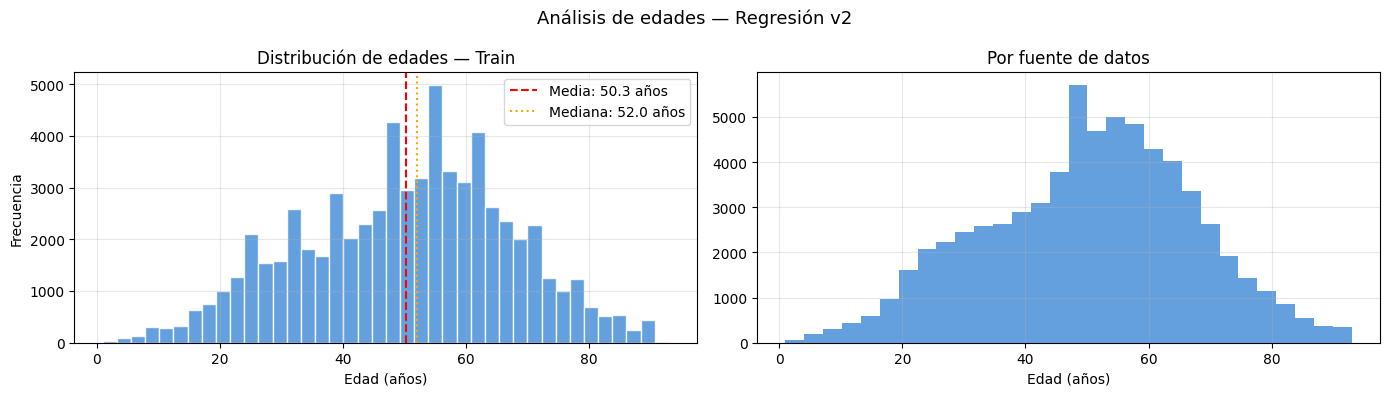

count    67031.0
mean        50.3
std         17.1
min          1.0
25%         38.0
50%         52.0
75%         62.0
max         93.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma general
axes[0].hist(df_train["edad"], bins=40, color="#4A90D9", alpha=0.85, edgecolor="white")
axes[0].axvline(edad_media,            color="red",    linestyle="--",
                label=f"Media: {edad_media:.1f} años")
axes[0].axvline(df_train["edad"].median(), color="orange", linestyle=":",
                label=f"Mediana: {df_train['edad'].median():.1f} años")
axes[0].set_title("Distribución de edades — Train")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Por fuente de datos
colores = {"nih":"#4A90D9","chexpert":"#E67E22"}
if "fuente" in df_train.columns:
    for fuente, color in colores.items():
        sub = df_train[df_train["fuente"]==fuente]["edad"]
        if len(sub) > 0:
            axes[1].hist(sub, bins=30, alpha=0.6,
                         label=f"{fuente.upper()} ({len(sub):,})", color=color)
    axes[1].legend()
else:
    axes[1].hist(df_train["edad"], bins=30, color="#4A90D9", alpha=0.85)
axes[1].set_title("Por fuente de datos")
axes[1].set_xlabel("Edad (años)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Análisis de edades — Regresión v2", fontsize=13)
plt.tight_layout()
plt.show()
print(df_train["edad"].describe().round(1).to_string())

## Celda 7 — Generadores de imágenes

`class_mode='raw'` es la diferencia clave con clasificación:
- Clasificación: `class_mode='binary'` → etiqueta es 0 o 1
- Regresión: `class_mode='raw'` → etiqueta es la edad normalizada (número continuo)


In [8]:
# ── Augmentation en TRAIN — simula variaciones reales de la toma ──────────────
gen_train = ImageDataGenerator(
    preprocessing_function = lambda x: x / 255.0,
    rotation_range         = 12,    # la radiografía puede estar ligeramente inclinada
    zoom_range             = 0.12,  # variaciones de distancia equipo-paciente
    horizontal_flip        = True,  # el tórax es casi simétrico
    width_shift_range      = 0.1, #antes 0.08
    height_shift_range     = 0.05, #antes 0.08
    fill_mode              = "nearest"
)

# ── Sin augmentation para val/test ────────────────────────────────────────────
gen_eval = ImageDataGenerator(preprocessing_function = lambda x: x / 255.0)

def crear_flujo(gen, df, mezclar=True):
    """
    class_mode='raw' → la etiqueta es el número exacto de edad_norm.
    Diferencia clave con clasificación: allí se usa class_mode='binary' o 'raw' con 0/1.
    Aquí la etiqueta es un número continuo (edad normalizada).
    """
    return gen.flow_from_dataframe(
        dataframe   = df,
        x_col       = "ruta_img",
        y_col       = "edad_norm",
        target_size = (TAMANO_IMAGEN, TAMANO_IMAGEN),
        color_mode  = "rgb",
        class_mode  = "raw",        # ← obligatorio para regresión
        batch_size  = BATCH_SIZE,
        shuffle     = mezclar,
        seed        = SEMILLA
    )

flujo_train = crear_flujo(gen_train, df_train, mezclar=True)
flujo_val   = crear_flujo(gen_eval,  df_val,   mezclar=False)
flujo_test  = crear_flujo(gen_eval,  df_test,  mezclar=False)

print("Generadores listos:")
print(f"  Pasos/epoch train : {len(flujo_train)}")
print(f"  Pasos/epoch val   : {len(flujo_val)}")

Found 67031 validated image filenames.
Found 14541 validated image filenames.
Found 14684 validated image filenames.
Generadores listos:
  Pasos/epoch train : 1048
  Pasos/epoch val   : 228


## Celda 8 — Arquitectura del modelo

**¿Por qué la cabeza es más grande que en v1?**

v1: `Dense(256) → Dense(1)` — simple y funcional
v2: `Dense(512) → BN → Dense(256) → BN → Dense(1)` — más capacidad + estabilidad

`BatchNormalization` normaliza las activaciones entre capas → gradientes más
estables durante el fine-tuning con 80 capas descongeladas.

`Huber loss` vs `MAE puro`: Huber es lineal para errores pequeños y cuadrático
amortiguado para errores grandes → menos sensible a pacientes con edades mal
registradas en los datasets.


In [9]:
# ── Cargar backbone pre-entrenado (congelado) ─────────────────────────────────
backbone = load_model(str(ruta_backbone), compile=False)
backbone.trainable = False   # congelar — la cabeza aprende primero

print("Backbone cargado:")
print(f"  Entrada : {backbone.input_shape}")
print(f"  Salida  : {backbone.output_shape}")
print(f"  Capas   : {len(backbone.layers)}")

# ── Cabeza de regresión (más grande y con BatchNorm vs v1) ────────────────────
x = backbone.output

# Si el backbone NO incluye GlobalAveragePooling (output shape 4D)
if len(x.shape) == 4:
    x = GlobalAveragePooling2D(name="pool_reg")(x)

# Dense(512) → BatchNorm → Dropout  [nuevo en v2: más capacidad]
x = Dense(512, activation="relu", name="dense_1")(x)
x = BatchNormalization(name="bn_1")(x)   # estabiliza el fine-tuning
x = Dropout(0.4, name="drop_1")(x)

# Dense(256) → BatchNorm → Dropout
x = Dense(256, activation="relu", name="dense_2")(x)
x = BatchNormalization(name="bn_2")(x)
x = Dropout(0.3, name="drop_2")(x)

# Capa final linear: puede predecir cualquier número (edad normalizada)
# relu estaría limitada a valores ≥0; sigmoid a [0,1] — ambas incorrectas
salida = Dense(1, activation="linear", name="edad_pred")(x)

modelo = Model(inputs=backbone.input, outputs=salida, name="regresion_v2")

# ── Compilar Fase 1 ───────────────────────────────────────────────────────────
# Huber loss (delta=1.5): robusto a outliers de edad
# MAE puro penaliza igual errores de 2 y 20 años
# Huber: para errores < delta → MAE lineal; > delta → cuadrático amortiguado
modelo.compile(
    optimizer = Adam(learning_rate=LR_FASE1),
    loss      = tf.keras.losses.Huber(delta=1.5),
    metrics   = ["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

params_tot  = modelo.count_params()
params_entr = sum(tf.size(w).numpy() for w in modelo.trainable_weights)
print(f"\nModelo construido:")
print(f"  Parámetros totales    : {params_tot:,}")
print(f"  Entrenables (F1)      : {params_entr:,}  ← solo cabeza")
print(f"  Congelados (backbone) : {params_tot - params_entr:,}")

Backbone cargado:
  Entrada : (None, 224, 224, 3)
  Salida  : (None, 7, 7, 1024)
  Capas   : 426

Modelo construido:
  Parámetros totales    : 7,696,961
  Entrenables (F1)      : 657,921  ← solo cabeza
  Congelados (backbone) : 7,039,040


## Celda 9 — Fase 1: entrenar solo la cabeza (backbone congelado)

In [10]:
cb_ckpt = ModelCheckpoint(
    filepath       = str(ruta_modelo),
    monitor        = "val_mae",
    mode           = "min",
    save_best_only = True,
    verbose        = 1
)
cb_early = EarlyStopping(
    monitor              = "val_mae",
    patience             = PACIENCIA_EARLY,
    restore_best_weights = True,
    verbose              = 1
)
cb_lr = ReduceLROnPlateau(
    monitor  = "val_mae",
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-6,
    verbose  = 1
)
callbacks = [cb_ckpt, cb_early, cb_lr]

print("=" * 55)
print("FASE 1 — Backbone congelado | Solo cabeza entrena")
print(f"  Epochs máx : {EPOCHS_FASE1}  |  LR : {LR_FASE1}")
if MUESTREO_ACTIVO:
    print(f"  ⚠️  Modo muestreo ({len(df_train):,} imgs) — resultados no finales")
print("=" * 55)

historia_f1 = modelo.fit(
    flujo_train,
    epochs            = EPOCHS_FASE1,
    validation_data   = flujo_val,
    callbacks         = callbacks,
    verbose           = 1
)

print(f"\nFase 1 completada.")
print(f"  Mejor val_mae (normalizado): {min(historia_f1.history['val_mae']):.4f}")
print(f"  ≈ {min(historia_f1.history['val_mae'])*edad_std:.1f} años reales")

FASE 1 — Backbone congelado | Solo cabeza entrena
  Epochs máx : 12  |  LR : 0.001
Epoch 1/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - loss: 0.5262 - mae: 0.8203 - rmse: 1.0637
Epoch 1: val_mae improved from None to 0.51642, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 804s 733ms/step - loss: 0.3445 - mae: 0.6542 - rmse: 0.8536 - val_loss: 0.2097 - val_mae: 0.5164 - val_rmse: 0.6494 - learning_rate: 0.0010
Epoch 2/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - loss: 0.2344 - mae: 0.5442 - rmse: 0.6878
Epoch 2: val_mae improved from 0.51642 to 0.51231, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 717s 684ms/step - loss: 0.2290 - mae: 0.5375 - rmse: 0.6796 - val_loss: 0.2064 - val_mae: 0.5123 - val_rmse: 0.6444 - learning_rate: 0.0010
Epoch 3/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 0.2222 - mae: 0.5288 - rmse: 0.6695
Epoch 3: val_mae did not improve from 0.51231
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 709s 677ms/step - loss: 0.2203 - mae: 0.5269 - rmse: 0.6667 - val_loss: 0.2118 - val_mae: 0.5224 - val_rmse: 0.6524 - learning_rate: 0.0010
Epoch 4/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - loss: 0.2149 - mae: 0.5213 - rmse: 0.6581
Epoch 4: val_mae improved from 0.51231 to 0.48514, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 714s 681ms/step - loss: 0.2140 - mae: 0.5190 - rmse: 0.6568 - val_loss: 0.1881 - val_mae: 0.4851 - val_rmse: 0.6152 - learning_rate: 0.0010
Epoch 5/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 0.2088 - mae: 0.5118 - rmse: 0.6484
Epoch 5: val_mae improved from 0.48514 to 0.48303, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 711s 679ms/step - loss: 0.2099 - mae: 0.5141 - rmse: 0.6503 - val_loss: 0.1875 - val_mae: 0.4830 - val_rmse: 0.6150 - learning_rate: 0.0010
Epoch 6/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 0.2076 - mae: 0.5095 - rmse: 0.6469
Epoch 6: val_mae improved from 0.48303 to 0.47823, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 713s 681ms/step - loss: 0.2074 - mae: 0.5099 - rmse: 0.6465 - val_loss: 0.1846 - val_mae: 0.4782 - val_rmse: 0.6099 - learning_rate: 0.0010
Epoch 7/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.2015 - mae: 0.5036 - rmse: 0.6371
Epoch 7: val_mae did not improve from 0.47823
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 711s 678ms/step - loss: 0.2023 - mae: 0.5045 - rmse: 0.6384 - val_loss: 0.1861 - val_mae: 0.4829 - val_rmse: 0.6123 - learning_rate: 0.0010
Epoch 8/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.2018 - mae: 0.5037 - rmse: 0.6372
Epoch 8: val_mae improved from 0.47823 to 0.47637, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 714s 681ms/step - loss: 0.2003 - mae: 0.5021 - rmse: 0.6349 - val_loss: 0.1810 - val_mae: 0.4764 - val_rmse: 0.6034 - learning_rate: 0.0010
Epoch 9/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - loss: 0.2014 - mae: 0.5023 - rmse: 0.6368
Epoch 9: val_mae improved from 0.47637 to 0.47287, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 710s 677ms/step - loss: 0.2000 - mae: 0.5011 - rmse: 0.6345 - val_loss: 0.1806 - val_mae: 0.4729 - val_rmse: 0.6034 - learning_rate: 0.0010
Epoch 10/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.1977 - mae: 0.4970 - rmse: 0.6309
Epoch 10: val_mae did not improve from 0.47287
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 711s 678ms/step - loss: 0.1968 - mae: 0.4965 - rmse: 0.6294 - val_loss: 0.1824 - val_mae: 0.4766 - val_rmse: 0.6064 - learning_rate: 0.0010
Epoch 11/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - loss: 0.1926 - mae: 0.4915 - rmse: 0.6224
Epoch 11: val_mae did not improve from 0.47287
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 715s 682ms/step - loss: 0.1938 - mae: 0.4923 - rmse: 0.6246 - val_loss: 0.1808 - val_mae: 0.4738 - val_rmse: 0.6029 - learning_rate: 0.0010
Epoch 12/12
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - loss: 0.1940 - mae: 0.4934 - rmse: 0.6249


Epoch 12: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 716s 683ms/step - loss: 0.1931 - mae: 0.4918 - rmse: 0.6234 - val_loss: 0.1778 - val_mae: 0.4645 - val_rmse: 0.5996 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 12.

Fase 1 completada.
  Mejor val_mae (normalizado): 0.4645
  ≈ 7.9 años reales


## Celda 10 — Fase 2: fine-tuning del backbone

Descongelamos las últimas 80 capas para especializarlas en radiografías.

**¿Por qué solo las últimas?**
- Primeras capas: detectan bordes y texturas — útiles para cualquier imagen
- Últimas capas: detectan patrones de alto nivel — específicos del dominio

`LR_FASE2 = 1e-5` (100× menor que Fase 1) para hacer ajustes finos sin borrar
lo aprendido con ImageNet.

**Resultado esperado:** el MAE baja 1-3 años adicionales respecto a Fase 1.


In [11]:
# ── Descongelar últimas N capas del backbone ──────────────────────────────────
total_capas = len(backbone.layers)
backbone.trainable = True
for i, capa in enumerate(backbone.layers):
    capa.trainable = (i >= total_capas - CAPAS_DESCONGELAR)

# Recompilar SIEMPRE después de cambiar trainable
modelo.compile(
    optimizer = Adam(learning_rate=LR_FASE2),
    loss      = tf.keras.losses.Huber(delta=1.5),
    metrics   = ["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

params_f2 = sum(tf.size(w).numpy() for w in modelo.trainable_weights)
print("=" * 55)
print("FASE 2 — Fine-tuning")
print(f"  Capas descongeladas : {CAPAS_DESCONGELAR} / {total_capas}")
print(f"  Parámetros entrena  : {params_f2:,}")
print(f"  LR (muy pequeño)    : {LR_FASE2}  ← no destruir pesos de ImageNet")
print("=" * 55)

historia_f2 = modelo.fit(
    flujo_train,
    epochs          = EPOCHS_FASE2,
    validation_data = flujo_val,
    callbacks       = callbacks,
    verbose         = 1
)

print(f"\nFase 2 completada.")
print(f"  Mejor val_mae (normalizado): {min(historia_f2.history['val_mae']):.4f}")
print(f"  ≈ {min(historia_f2.history['val_mae'])*edad_std:.1f} años reales")

FASE 2 — Fine-tuning
  Capas descongeladas : 80 / 426
  Parámetros entrena  : 2,294,913
  LR (muy pequeño)    : 0.0001  ← no destruir pesos de ImageNet
Epoch 1/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - loss: 0.1694 - mae: 0.4590 - rmse: 0.5833
Epoch 1: val_mae improved from 0.46449 to 0.44878, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 808s 725ms/step - loss: 0.1583 - mae: 0.4430 - rmse: 0.5637 - val_loss: 0.1638 - val_mae: 0.4488 - val_rmse: 0.5739 - learning_rate: 1.0000e-04
Epoch 2/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - loss: 0.1324 - mae: 0.4055 - rmse: 0.5155
Epoch 2: val_mae improved from 0.44878 to 0.37658, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 714s 681ms/step - loss: 0.1301 - mae: 0.4016 - rmse: 0.5108 - val_loss: 0.1160 - val_mae: 0.3766 - val_rmse: 0.4826 - learning_rate: 1.0000e-04
Epoch 3/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 0.1196 - mae: 0.3855 - rmse: 0.4893
Epoch 3: val_mae did not improve from 0.37658
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 709s 677ms/step - loss: 0.1198 - mae: 0.3857 - rmse: 0.4900 - val_loss: 0.1200 - val_mae: 0.3823 - val_rmse: 0.4913 - learning_rate: 1.0000e-04
Epoch 4/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - loss: 0.1145 - mae: 0.3763 - rmse: 0.4791
Epoch 4: val_mae improved from 0.37658 to 0.37460, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 715s 682ms/step - loss: 0.1137 - mae: 0.3746 - rmse: 0.4773 - val_loss: 0.1151 - val_mae: 0.3746 - val_rmse: 0.4809 - learning_rate: 1.0000e-04
Epoch 5/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - loss: 0.1076 - mae: 0.3647 - rmse: 0.4643
Epoch 5: val_mae did not improve from 0.37460
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 717s 684ms/step - loss: 0.1084 - mae: 0.3659 - rmse: 0.4660 - val_loss: 0.1261 - val_mae: 0.3935 - val_rmse: 0.5031 - learning_rate: 1.0000e-04
Epoch 6/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - loss: 0.1040 - mae: 0.3593 - rmse: 0.4564
Epoch 6: val_mae improved from 0.37460 to 0.35409, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 726s 693ms/step - loss: 0.1049 - mae: 0.3601 - rmse: 0.4585 - val_loss: 0.1032 - val_mae: 0.3541 - val_rmse: 0.4553 - learning_rate: 1.0000e-04
Epoch 7/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 0.1010 - mae: 0.3545 - rmse: 0.4497
Epoch 7: val_mae did not improve from 0.35409
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 709s 677ms/step - loss: 0.1014 - mae: 0.3548 - rmse: 0.4505 - val_loss: 0.1040 - val_mae: 0.3548 - val_rmse: 0.4570 - learning_rate: 1.0000e-04
Epoch 8/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.0989 - mae: 0.3499 - rmse: 0.4450
Epoch 8: val_mae did not improve from 0.35409
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 711s 678ms/step - loss: 0.0972 - mae: 0.3464 - rmse: 0.4413 - val_loss: 0.1040 - val_mae: 0.3569 - val_rmse: 0.4575 - learning_rate: 1.0000e-04
Epoch 9/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 0.0957 - mae: 0.3448 - rmse:

...


Epoch 11: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 715s 682ms/step - loss: 0.0915 - mae: 0.3369 - rmse: 0.4280 - val_loss: 0.0979 - val_mae: 0.3468 - val_rmse: 0.4436 - learning_rate: 1.0000e-04
Epoch 12/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 0.0882 - mae: 0.3307 - rmse: 0.4202
Epoch 12: val_mae did not improve from 0.34677
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 709s 677ms/step - loss: 0.0888 - mae: 0.3319 - rmse: 0.4216 - val_loss: 0.1007 - val_mae: 0.3498 - val_rmse: 0.4494 - learning_rate: 1.0000e-04
Epoch 13/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.0884 - mae: 0.3309 - rmse: 0.4208
Epoch 13: val_mae improved from 0.34677 to 0.34594, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 13: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 715s 682ms/step - loss: 0.0886 - mae: 0.3310 - rmse: 0.4212 - val_loss: 0.0988 - val_mae: 0.3459 - val_rmse: 0.4454 - learning_rate: 1.0000e-04
Epoch 14/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.0858 - mae: 0.3264 - rmse: 0.4143
Epoch 14: val_mae did not improve from 0.34594
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 711s 679ms/step - loss: 0.0863 - mae: 0.3267 - rmse: 0.4157 - val_loss: 0.1029 - val_mae: 0.3521 - val_rmse: 0.4545 - learning_rate: 1.0000e-04
Epoch 15/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - loss: 0.0852 - mae: 0.3261 - rmse: 0.4130
Epoch 15: val_mae improved from 0.34594 to 0.34077, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 15: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 716s 683ms/step - loss: 0.0843 - mae: 0.3234 - rmse: 0.4108 - val_loss: 0.0963 - val_mae: 0.3408 - val_rmse: 0.4397 - learning_rate: 1.0000e-04
Epoch 16/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 0.0840 - mae: 0.3224 - rmse: 0.4101
Epoch 16: val_mae improved from 0.34077 to 0.33760, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 16: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 713s 680ms/step - loss: 0.0838 - mae: 0.3222 - rmse: 0.4096 - val_loss: 0.0949 - val_mae: 0.3376 - val_rmse: 0.4365 - learning_rate: 1.0000e-04
Epoch 17/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - loss: 0.0817 - mae: 0.3185 - rmse: 0.4044
Epoch 17: val_mae did not improve from 0.33760
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 714s 681ms/step - loss: 0.0823 - mae: 0.3193 - rmse: 0.4060 - val_loss: 0.1022 - val_mae: 0.3506 - val_rmse: 0.4529 - learning_rate: 1.0000e-04
Epoch 18/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - loss: 0.0808 - mae: 0.3166 - rmse: 0.4023
Epoch 18: val_mae improved from 0.33760 to 0.33601, saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5



Epoch 18: finished saving model to /content/drive/MyDrive/Vena/checkpoints/regresion_v3.h5
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 711s 678ms/step - loss: 0.0812 - mae: 0.3176 - rmse: 0.4031 - val_loss: 0.0929 - val_mae: 0.3360 - val_rmse: 0.4320 - learning_rate: 1.0000e-04
Epoch 19/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - loss: 0.0777 - mae: 0.3111 - rmse: 0.3942
Epoch 19: val_mae did not improve from 0.33601
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 712s 679ms/step - loss: 0.0788 - mae: 0.3129 - rmse: 0.3971 - val_loss: 0.1021 - val_mae: 0.3510 - val_rmse: 0.4526 - learning_rate: 1.0000e-04
Epoch 20/20
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - loss: 0.0783 - mae: 0.3125 - rmse: 0.3960
Epoch 20: val_mae did not improve from 0.33601
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 713s 681ms/step - loss: 0.0786 - mae: 0.3125 - rmse: 0.3967 - val_loss: 0.0935 - val_mae: 0.3361 - val_rmse: 0.4336 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 18.

Fase 2 completada.
  Mejor

## Celda 11 — Curvas de entrenamiento

Gráfica guardada en: /content/drive/MyDrive/Vena/checkpoints/curvas_regresion_v2.png


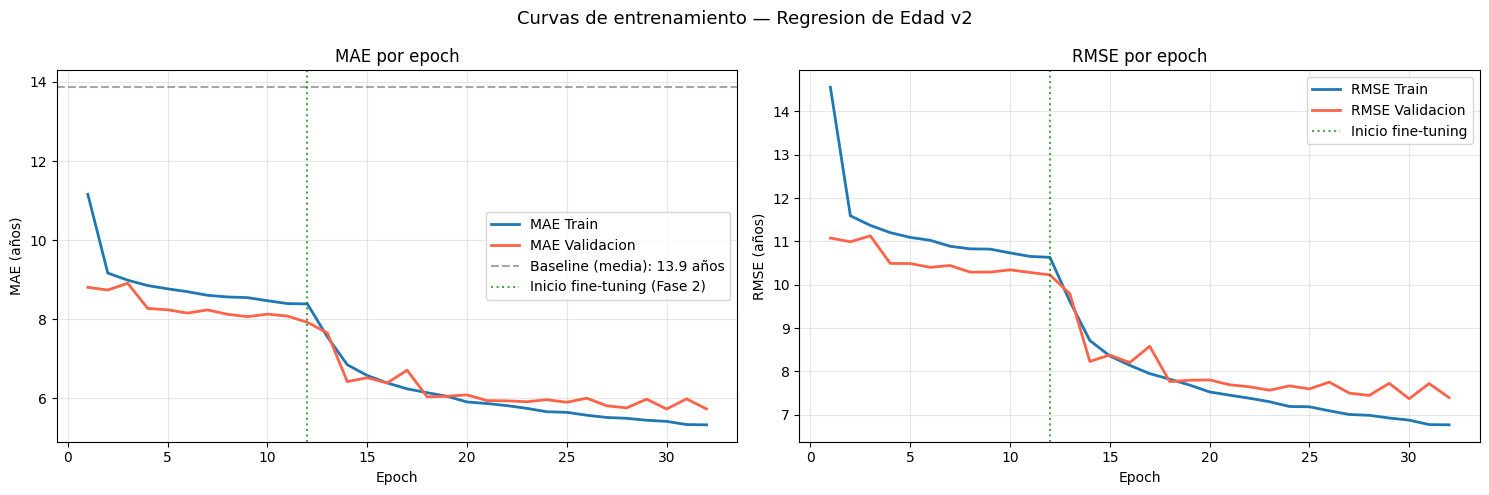

In [12]:
mae_tr  = historia_f1.history["mae"]     + historia_f2.history["mae"]
mae_va  = historia_f1.history["val_mae"] + historia_f2.history["val_mae"]
rmse_tr = historia_f1.history["rmse"]    + historia_f2.history["rmse"]
rmse_va = historia_f1.history["val_rmse"]+ historia_f2.history["val_rmse"]
epochs  = range(1, len(mae_tr) + 1)
fin_f1  = len(historia_f1.history["mae"])

# Desnormalizar a años reales
mae_tr_a  = [m * edad_std for m in mae_tr]
mae_va_a  = [m * edad_std for m in mae_va]
rmse_tr_a = [m * edad_std for m in rmse_tr]
rmse_va_a = [m * edad_std for m in rmse_va]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# MAE
ax1.plot(epochs, mae_tr_a,  label="MAE Train",     linewidth=2)
ax1.plot(epochs, mae_va_a,  label="MAE Validacion", linewidth=2, color="tomato")
ax1.axhline(baseline_mae, color="gray", linestyle="--", alpha=0.7,
            label=f"Baseline (media): {baseline_mae:.1f} años")
ax1.axvline(fin_f1, color="green", linestyle=":", alpha=0.7, label="Inicio fine-tuning (Fase 2)")
ax1.set_title("MAE por epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MAE (años)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# RMSE
ax2.plot(epochs, rmse_tr_a, label="RMSE Train",     linewidth=2)
ax2.plot(epochs, rmse_va_a, label="RMSE Validacion", linewidth=2, color="tomato")
ax2.axvline(fin_f1, color="green", linestyle=":", alpha=0.7, label="Inicio fine-tuning")
ax2.set_title("RMSE por epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("RMSE (años)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento — Regresion de Edad v2", fontsize=13)
plt.tight_layout()
ruta_curvas = ruta_checkpoints / "curvas_regresion_v2.png"
plt.savefig(str(ruta_curvas), dpi=150, bbox_inches="tight")
print(f"Gráfica guardada en: {ruta_curvas}")
plt.show()

## Celda 12 — Evaluación en test

Métricas de referencia:
- MAE < 8 años → excelente (v1 obtuvo 6.9)
- R² > 0.6 → excelente (v1 obtuvo 0.711)
- Baseline (predecir siempre la media): ~13 años — el modelo debe superarlo


Generando predicciones en test...
230/230 ━━━━━━━━━━━━━━━━━━━━ 48s 159ms/step

══════════════════════════════════════════════════
RESULTADOS EN TEST
  MAE  : 5.81 años   (v1: 6.9)
  RMSE : 7.42 años  (v1: 8.8)
  R²   : 0.813          (v1: 0.711)
  Baseline MAE (media): 13.87 años
══════════════════════════════════════════════════
Scatter guardado: /content/drive/MyDrive/Vena/checkpoints/scatter_regresion_v2.png


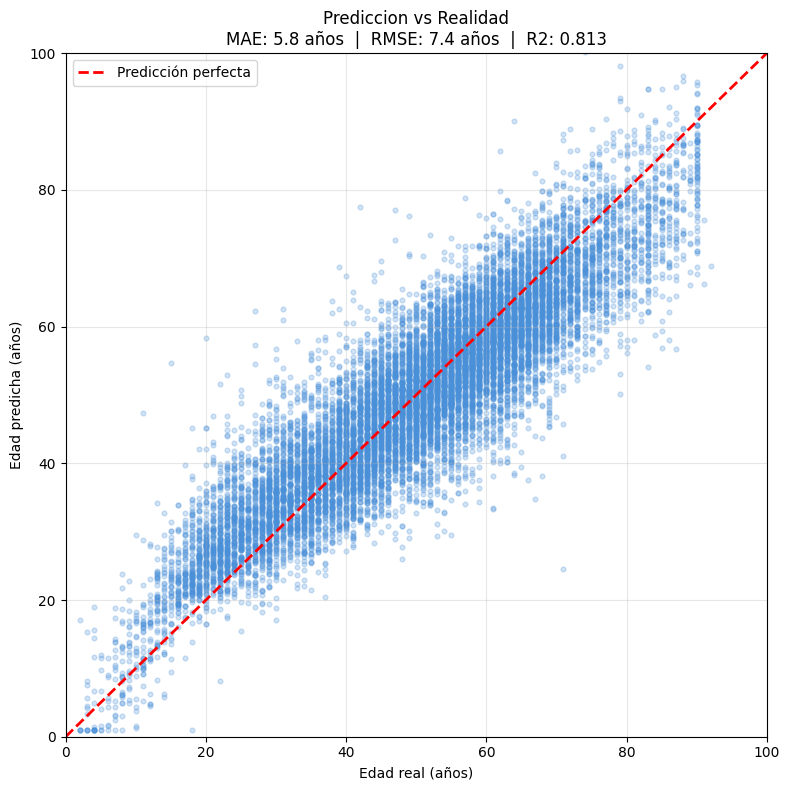

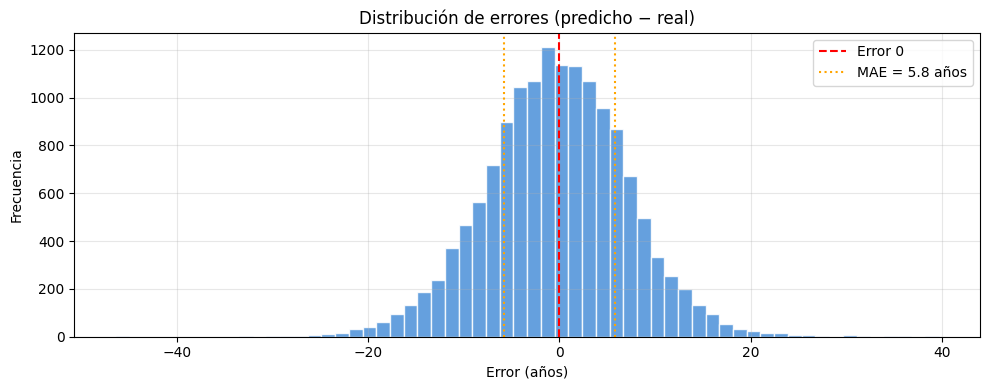

In [13]:
from sklearn.metrics import r2_score

mejor = load_model(str(ruta_modelo), compile=False)
mejor.compile(optimizer="adam", loss=tf.keras.losses.Huber(delta=1.5),
              metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")])

print("Generando predicciones en test...")
flujo_test.reset()
pred_norm = mejor.predict(flujo_test, verbose=1)
pred_norm = pred_norm[:len(df_test)]

# Desnormalizar: de escala estándar → años reales
pred_anios = scaler_edad.inverse_transform(pred_norm.reshape(-1,1)).flatten()
real_anios = df_test["edad"].values
pred_anios = np.clip(pred_anios, 1, 110)

mae  = np.mean(np.abs(pred_anios - real_anios))
rmse = np.sqrt(np.mean((pred_anios - real_anios)**2))
r2   = r2_score(real_anios, pred_anios)

print(f"\n{'═'*50}")
print("RESULTADOS EN TEST")
print(f"  MAE  : {mae:.2f} años   (v1: 6.9)")
print(f"  RMSE : {rmse:.2f} años  (v1: 8.8)")
print(f"  R²   : {r2:.3f}          (v1: 0.711)")
print(f"  Baseline MAE (media): {baseline_mae:.2f} años")
print(f"{'═'*50}")

# Scatter: edad real vs predicha
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(real_anios, pred_anios, alpha=0.25, s=12, color="#4A90D9")
lim = [0, 100]
ax.plot(lim, lim, "r--", linewidth=2, label="Predicción perfecta")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Edad real (años)")
ax.set_ylabel("Edad predicha (años)")
ax.set_title(f"Prediccion vs Realidad\nMAE: {mae:.1f} años  |  RMSE: {rmse:.1f} años  |  R2: {r2:.3f}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
ruta_scatter = ruta_checkpoints / "scatter_regresion_v2.png"
plt.savefig(str(ruta_scatter), dpi=150, bbox_inches="tight")
print(f"Scatter guardado: {ruta_scatter}")
plt.show()

# Histograma de errores
errores = pred_anios - real_anios
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(errores, bins=60, color="#4A90D9", alpha=0.85, edgecolor="white")
ax.axvline(0,    color="red",    linestyle="--", label="Error 0")
ax.axvline(mae,  color="orange", linestyle=":",  label=f"MAE = {mae:.1f} años")
ax.axvline(-mae, color="orange", linestyle=":")
ax.set_title("Distribución de errores (predicho − real)")
ax.set_xlabel("Error (años)")
ax.set_ylabel("Frecuencia")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(ruta_checkpoints / "histograma_errores_v2.png"), dpi=150, bbox_inches="tight")
plt.show()

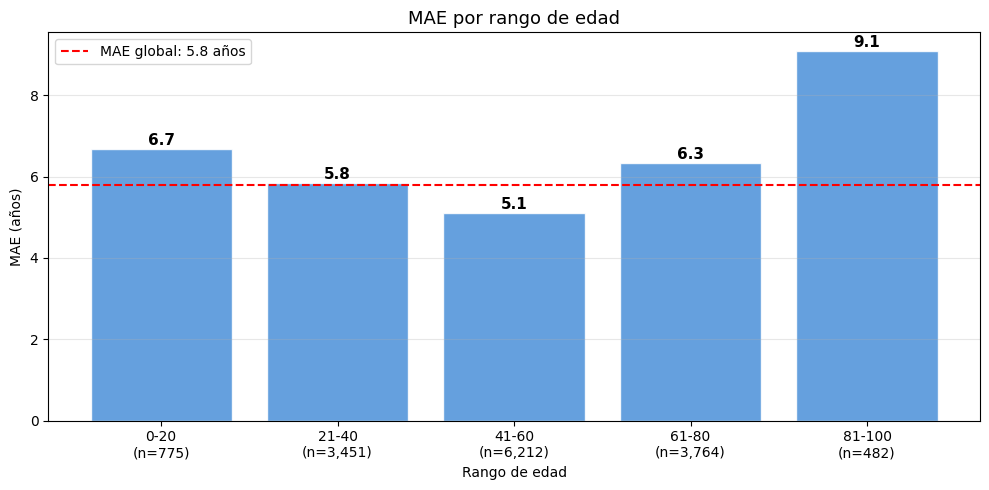

In [14]:

rangos = [(1,20,"0-20"), (21,40,"21-40"), (41,60,"41-60"),
          (61,80,"61-80"), (81,100,"81-100")]

mae_por_rango = []
etiquetas     = []
for lo, hi, label in rangos:
    mask = (real_anios >= lo) & (real_anios <= hi)
    if mask.sum() > 0:
        mae_r = np.mean(np.abs(pred_anios[mask] - real_anios[mask]))
        mae_por_rango.append(mae_r)
        etiquetas.append(f"{label}\n(n={mask.sum():,})")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(etiquetas, mae_por_rango, color="#4A90D9", alpha=0.85, edgecolor="white")
ax.axhline(mae, color="red", linestyle="--", label=f"MAE global: {mae:.1f} años")
for bar, val in zip(bars, mae_por_rango):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.set_title("MAE por rango de edad", fontsize=13)
ax.set_xlabel("Rango de edad")
ax.set_ylabel("MAE (años)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(str(ruta_checkpoints / "mae_por_rango_v2.png"), dpi=150, bbox_inches="tight")
plt.show()

##Visualización de predicciones reales


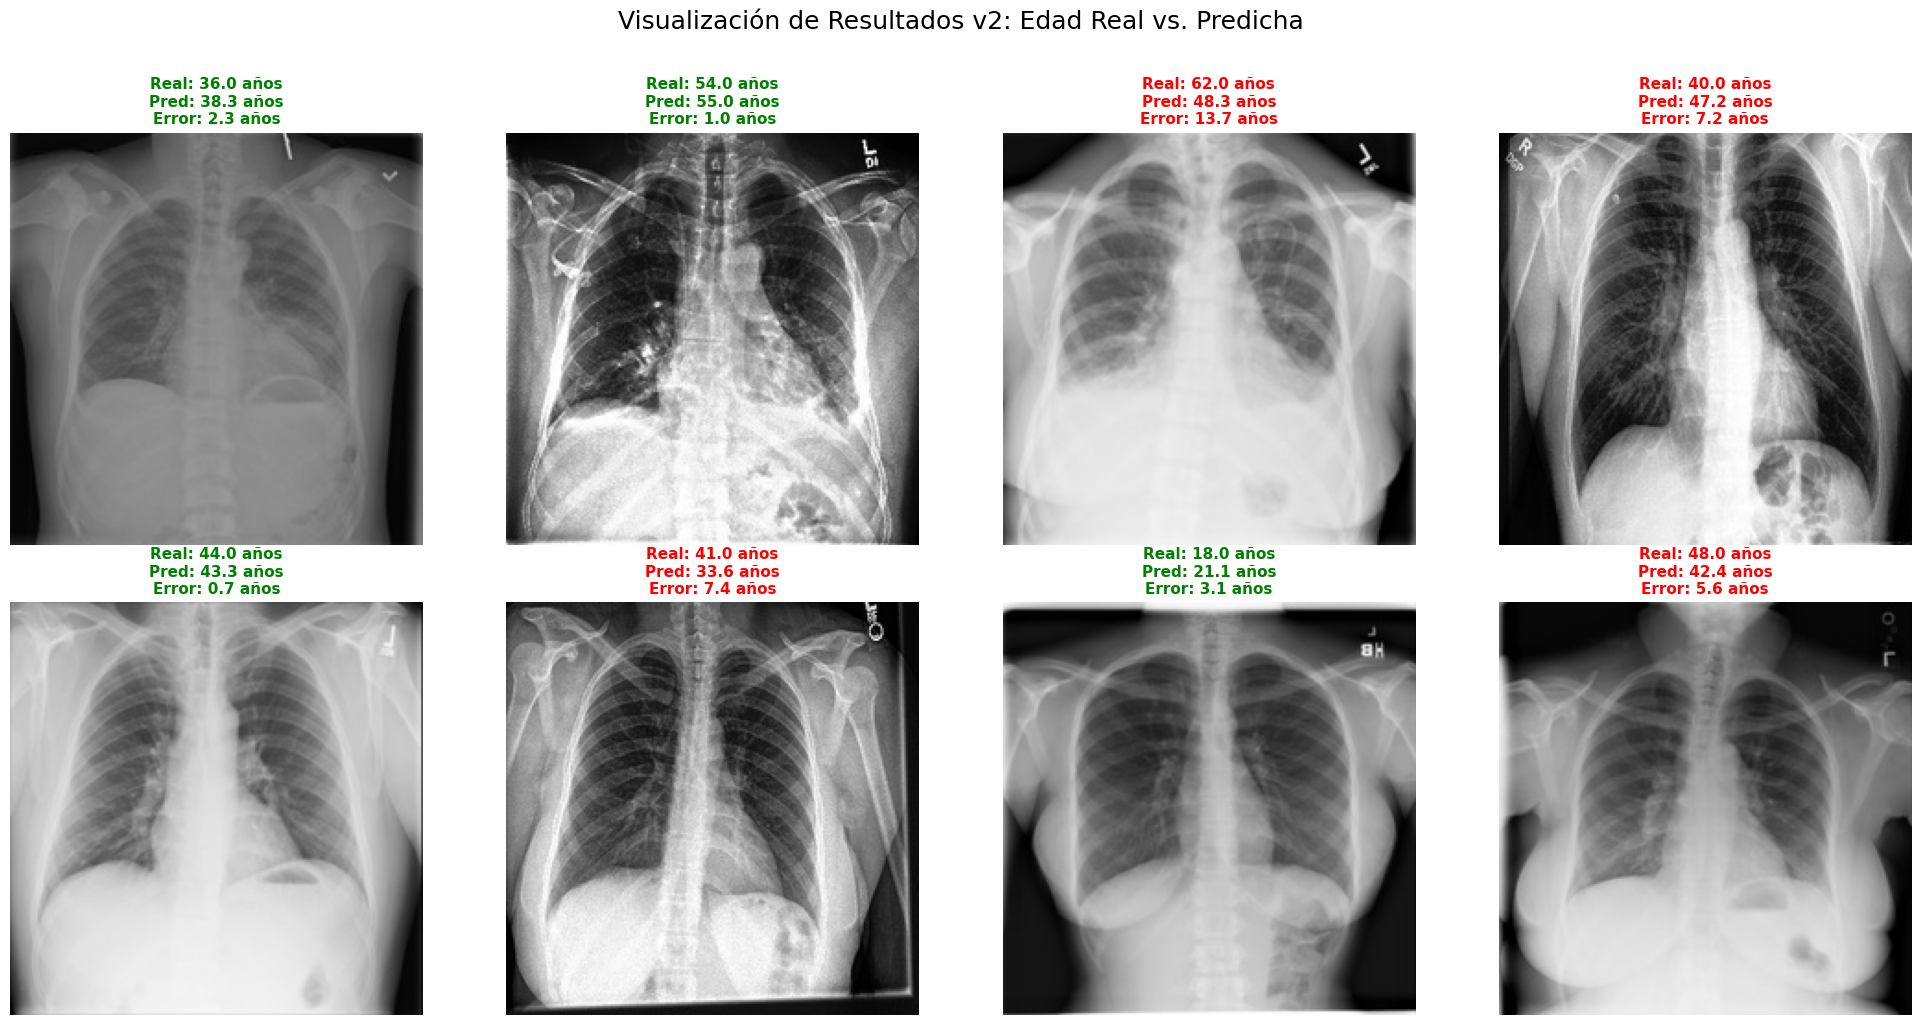

In [21]:
import cv2
import matplotlib.pyplot as plt

# 1. Seleccionar una muestra aleatoria de imágenes del set de test
n_ejemplos = 8
indices = np.random.choice(len(df_test), n_ejemplos, replace=False)

plt.figure(figsize=(20, 10))

for i, idx in enumerate(indices):
    # Obtener la ruta de la imagen y las edades (ya desnormalizadas en Celda 12)
    ruta = df_test.iloc[idx]["ruta_img"]
    real = df_test.iloc[idx]["edad"]
    pred = pred_anios[idx]
    error = abs(real - pred)

    # Cargar y preparar la imagen
    img = cv2.imread(ruta)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Graficar
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)

    # Color del título: verde si el error es menor a 5 años, rojo si es mayor
    color_titulo = "green" if error < 5 else "red"

    plt.title(f"Real: {real:.1f} años\nPred: {pred:.1f} años\nError: {error:.1f} años",
              color=color_titulo, fontsize=11, fontweight='bold')
    plt.axis("off")

plt.suptitle("Visualización de Resultados v2: Edad Real vs. Predicha", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(str(ruta_checkpoints / "visualizacion_radiografias_v2_6.png"), dpi=150, bbox_inches="tight")
plt.show()

## Celda 13 — Guardar backbone fine-tuneado para NB04

In [16]:
# Guardar el backbone fine-tuneado para el NB04 de clustering
from tensorflow.keras.models import Model

# Buscar la capa pool para extraer el backbone sin la cabeza
capa_pool = next(
    (l for l in modelo.layers if "pool" in l.name or "global" in l.name.lower()),
    None
)
if capa_pool:
    backbone_reg = Model(
        inputs  = modelo.input,
        outputs = capa_pool.output,
        name    = "backbone_reg_v2"
    )
    backbone_reg.save(str(ruta_backbone_reg))
    print(f"Backbone fine-tuneado guardado: {ruta_backbone_reg}")
else:
    print("No se encontró la capa pool — guardando modelo completo")

print("\nArchivos en checkpoints/:")
for f in sorted(ruta_checkpoints.iterdir()):
    print(f"  {f.name:<45} ({f.stat().st_size/1024/1024:.1f} MB)")

Backbone fine-tuneado guardado: /content/drive/MyDrive/Vena/checkpoints/backbone_reg_v2.h5

Archivos en checkpoints/:
  analisis_edades.png                           (0.1 MB)
  backbone_densenet121.h5                       (28.1 MB)
  backbone_densenet121_prueba.h5                (28.1 MB)
  backbone_densenet121_v2.h5                    (28.1 MB)
  backbone_densenet121_v3.h5                    (28.1 MB)
  backbone_reg_v2.h5                            (0.1 MB)
  clustering_radiografias.png                   (1.2 MB)
  curvas_entrenamiento_clasificacion.png        (0.1 MB)
  curvas_entrenamiento_clasificacion_v2.png     (0.1 MB)
  curvas_entrenamiento_prueba.png               (0.1 MB)
  curvas_entrenamiento_regresion.png            (0.1 MB)
  curvas_regresion_v2.png                       (0.1 MB)
  histograma_errores_v2.png                     (0.0 MB)
  mae_por_rango_v2.png                          (0.0 MB)
  matriz_confusion_clasificacion.png            (0.0 MB)
  matriz_confusion_clas